In [1]:
%load_ext autoreload    
%autoreload 2

In [ ]:
import cvxpy as cp
import qutip as qt
import numpy as np
import matplotlib.pyplot as plt
import plots as plots

# New structure imports
from spins_sdp.models import (
    ising_hamiltonian_exact,
    ising_hamiltonian_dict,
    heisenberg_hamiltonian_exact,
    heisenberg_hamiltonian_dict,
)
from spins_sdp.basis_builder import (
    generate_npa_basis,
    generate_heisenberg_paper_basis,
)
from spins_sdp.utils import (
    benchmark_exact_diagonalization,
    benchmark_npa_relaxation,
    benchmark_relaxation,
)

from spins_sdp.utils import *

## 1. Exact Diagonalization

In [ ]:
# Model parameters
N = 2
J = 1.0
h = 0
k = 0
boundary = "periodic"
beta = 1.0
axis = 'z'

# create hamiltonian
H = ising_hamiltonian_exact(N, J, h, k, boundary=boundary)
eigenvalues, eigenstates = H.eigenstates()

# Ground state
E0 = eigenvalues[0]
psi0 = eigenstates[0]

## 2. SDP Relaxation (Ground State Energy)

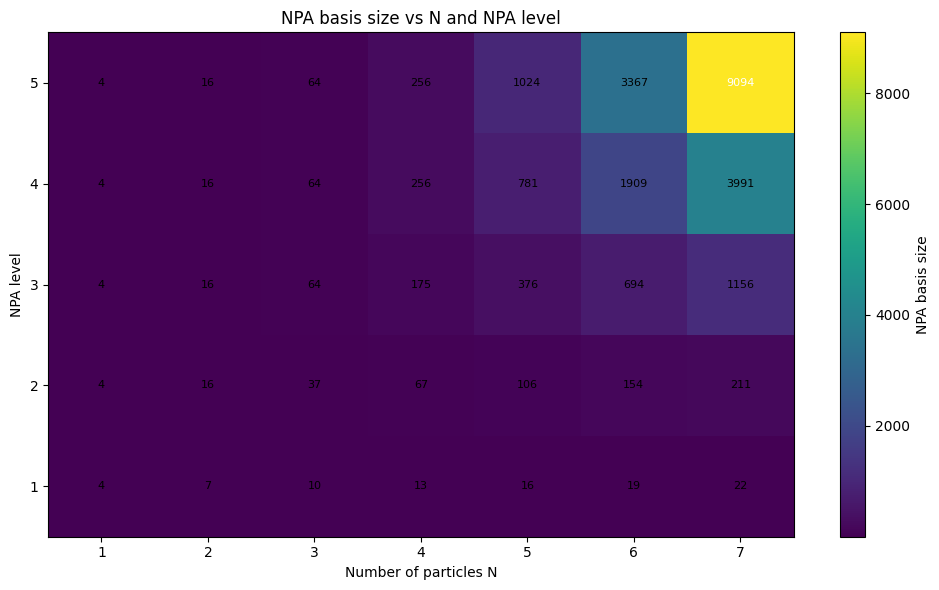

In [4]:
plots.npa_basis_size_heatmap(N=7, max_NPA_level=5)


Computed E_lb/N from function: -0.9999999999996101
Exact E0/N: [-1.]


/Users/cisco/_Code/MyRepositories/SpinsSDP/.venv/lib/python3.13/site-packages/cvxpy/atoms/affine/binary_operators.py:116: RuntimeWarning: divide by zero encountered in matmul
  return np.matmul(values[0], values[1])
/Users/cisco/_Code/MyRepositories/SpinsSDP/.venv/lib/python3.13/site-packages/cvxpy/atoms/affine/binary_operators.py:116: RuntimeWarning: overflow encountered in matmul
  return np.matmul(values[0], values[1])
/Users/cisco/_Code/MyRepositories/SpinsSDP/.venv/lib/python3.13/site-packages/cvxpy/atoms/affine/binary_operators.py:116: RuntimeWarning: invalid value encountered in matmul
  return np.matmul(values[0], values[1])


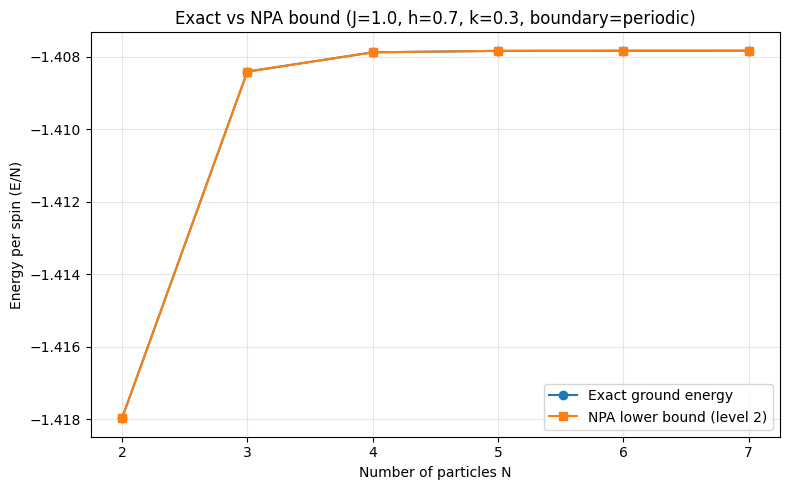

/Users/cisco/_Code/MyRepositories/SpinsSDP/plots.py:444: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.yscale("log")


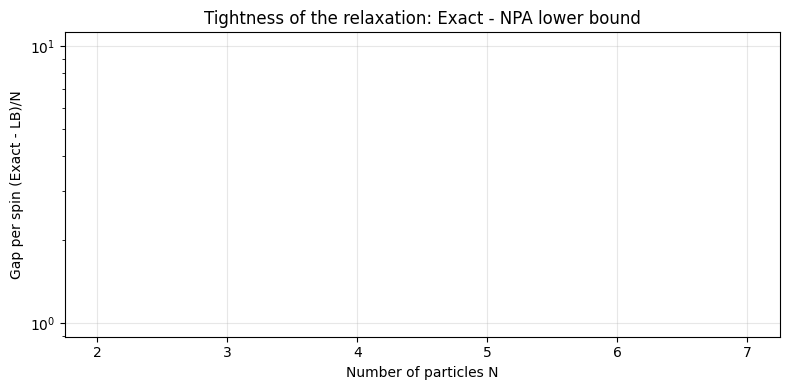

In [ ]:
# SDP parameters
NPA_level = 2
N = 2
solver = "MOSEK"

# Tighter Mosek tolerances to reduce gap issues
solver_opts = {
    "mosek_params": {
        "MSK_DPAR_INTPNT_CO_TOL_REL_GAP": 1e-12,
        "MSK_DPAR_INTPNT_CO_TOL_PFEAS": 1e-12,
        "MSK_DPAR_INTPNT_CO_TOL_DFEAS": 1e-12,
    },
}

exact_E = H.eigenstates(eigvals=1)[0]

# TODO: use the more general solve_pauli_relaxation instead of deprecated npa_lb_energy 
# E_lb_val = npa_lb_energy(
#     J=J, h=h, k=k,
#     N=N,
#     NPA_level=NPA_level,
#     solver=solver,
#     boundary=boundary,
#     solver_opts=solver_opts,
#  )
#
# print(f"Computed E_lb/N from function: {E_lb_val/N}")
# print(f"Exact E0/N: {exact_E/N}")


Ns, E_exact, E_lb = plots.plot_exact_vs_npa_energy_vs_N(
    N_values=range(2, 8),
    J=1.0, h=0.7, k=0.3,
    NPA_level=2,
    boundary="periodic",
    solver=solver,
    solver_opts=solver_opts,
    per_site=True
)   

#  Bug/Numerical error somewhere since the NPA lower bound is above the exact energy for some N.

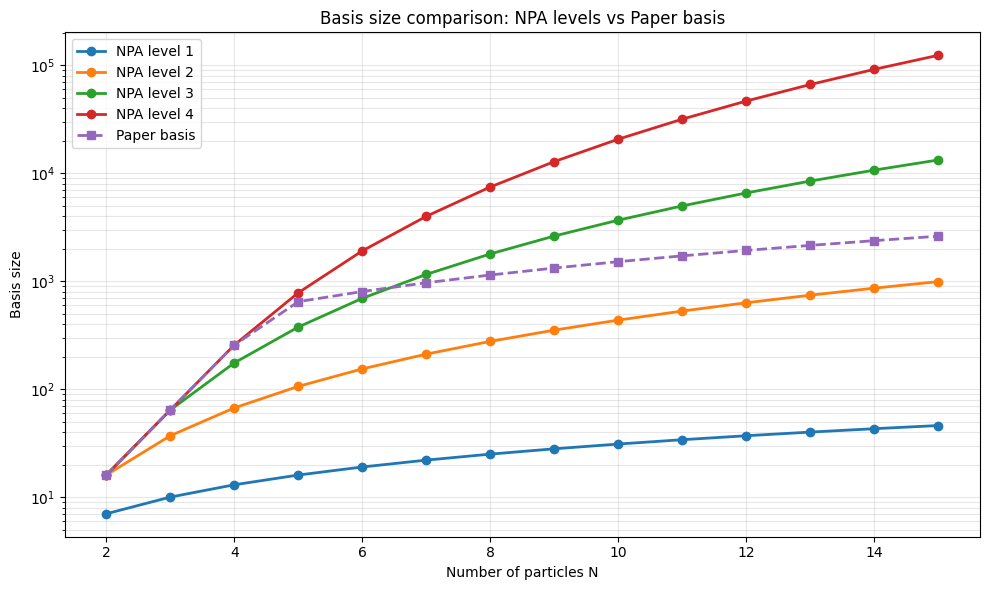

In [6]:
basis_comparison = plots.plot_basis_size_comparison(
    N_values=range(2, 16),
    npa_levels=[1, 2, 3, 4],
    include_paper_basis=True,
    logy=True,
)

We see that the paper basis only beats NPA level 3 at N=7

In [7]:
exact_data = benchmark_exact_diagonalization(
    N_values=range(2, 13),
    J=J, h=h, k=k,
    boundary="periodic",
    repeats=1,
)

In [8]:
npa_data_1 = benchmark_npa_relaxation(
    N_values=range(2, 25),
    NPA_level=1,
    J=J, h=h, k=k,
    boundary="periodic",
    solver="MOSEK",
    repeats=1,
)

/Users/cisco/_Code/MyRepositories/SpinsSDP/.venv/lib/python3.13/site-packages/cvxpy/atoms/affine/binary_operators.py:116: RuntimeWarning: divide by zero encountered in matmul
  return np.matmul(values[0], values[1])
/Users/cisco/_Code/MyRepositories/SpinsSDP/.venv/lib/python3.13/site-packages/cvxpy/atoms/affine/binary_operators.py:116: RuntimeWarning: overflow encountered in matmul
  return np.matmul(values[0], values[1])
/Users/cisco/_Code/MyRepositories/SpinsSDP/.venv/lib/python3.13/site-packages/cvxpy/atoms/affine/binary_operators.py:116: RuntimeWarning: invalid value encountered in matmul
  return np.matmul(values[0], values[1])


In [9]:
npa_data_2 = benchmark_npa_relaxation(
    N_values=range(2, 8),
    NPA_level=2,
    J=J, h=h, k=k,
    boundary="periodic",
    solver="MOSEK",
    repeats=1,
)

In [10]:
npa_data_3 = benchmark_npa_relaxation(
    N_values=range(2, 7),
    NPA_level=3,
    J=J, h=h, k=k,
    boundary="periodic",
    solver="MOSEK",
    repeats=1,
)

In [ ]:
paper_data = benchmark_relaxation(
    N_values=range(2, 5),
    basis_fn=lambda N: generate_heisenberg_paper_basis(N=N),
    operator_fn=lambda N: ising_hamiltonian_dict(N=N, J=J, h=h, k=k, boundary="periodic"),
    sense="min",
    solver="MOSEK",
    repeats=1
)

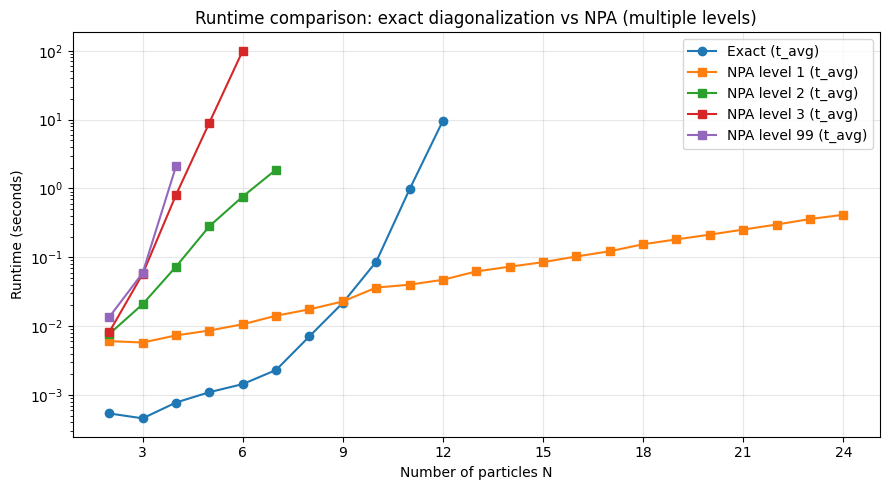

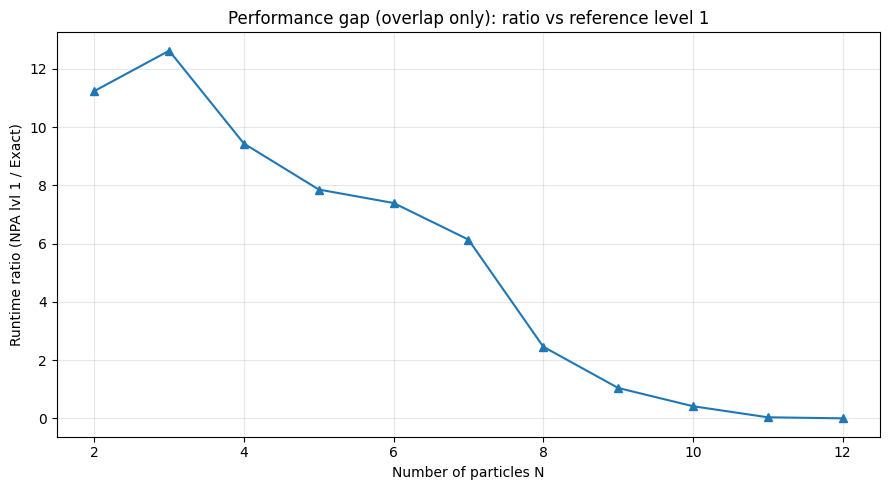

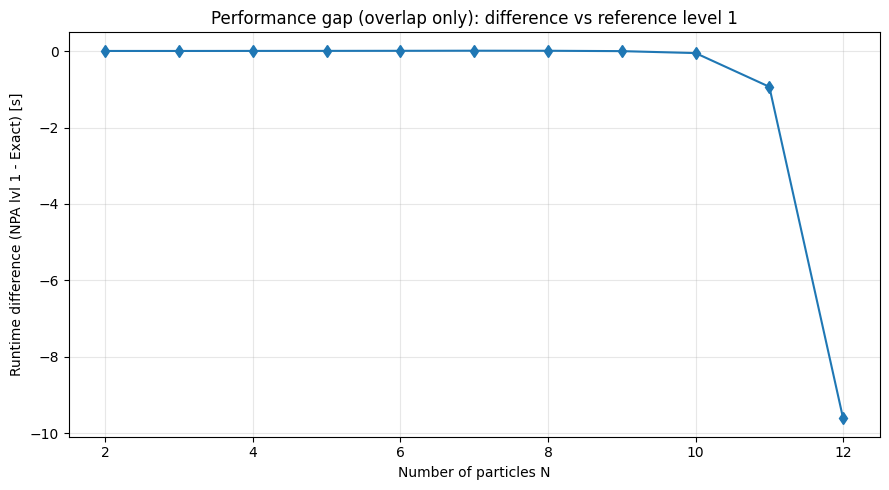

In [12]:
npa_data_by_level = {
    1: npa_data_1,
    2: npa_data_2,
    3: npa_data_3,
    99: paper_data
}

out = plots.plot_runtime_comparison_multi_levels(
    exact_data=exact_data,
    npa_data_by_level=npa_data_by_level,
    levels=[1,2,3,99],
    use="t_avg",
    logy=True,
)

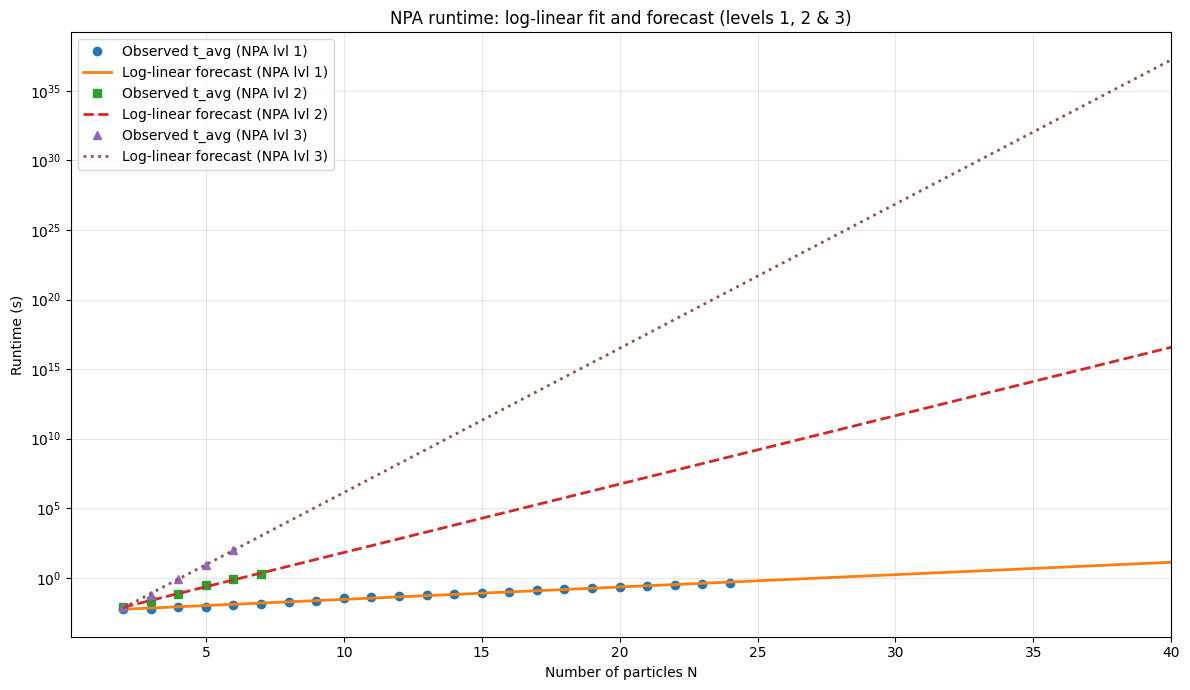

NPA Level 1:
  Fit: log t = 0.204637 * N + -5.61381
  R^2 (log-scale): 0.99236
  Forecast at N=10: 2.823e-02 s (0.00 min)
  Forecast at N=20: 2.185e-01 s (0.00 min)
  Forecast at N=30: 1.691e+00 s (0.03 min)
  Forecast at N=40: 1.309e+01 s (0.22 min)

NPA Level 2:
  Fit: log t = 1.13246 * N + -7.13744
  R^2 (log-scale): 0.99590
  Forecast at N=10: 6.583e+01 s (1.10 min)
  Forecast at N=20: 5.453e+06 s (90882.12 min)
  Forecast at N=30: 4.517e+11 s (7527808762.67 min)
  Forecast at N=40: 3.741e+16 s (623531925286346.25 min)

NPA Level 3:
  Fit: log t = 2.38756 * N + -9.76327
  R^2 (log-scale): 0.99818
  Forecast at N=10: 1.346e+06 s (22425.29 min)
  Forecast at N=20: 3.147e+16 s (524519884065010.75 min)
  Forecast at N=30: 7.361e+26 s (12268339501971572111966208.00 min)
  Forecast at N=40: 1.722e+37 s (286952237099516654113313072470818816.00 min)


In [13]:
# Log-linear regression on NPA runtimes (t_avg) and forecast to N=40
import numpy as np
import matplotlib.pyplot as plt

# --- NPA Level 1 ---
N_obs_1 = np.array(npa_data_1["N"], dtype=float)
t_obs_1 = np.array(npa_data_1["t_avg"], dtype=float)

mask_1 = t_obs_1 > 0
N_obs_1 = N_obs_1[mask_1]
t_obs_1 = t_obs_1[mask_1]

coef_1 = np.polyfit(N_obs_1, np.log(t_obs_1), 1)
a_1, b_1 = coef_1
predict_1 = lambda N: np.exp(a_1 * N + b_1)

log_pred_1 = a_1 * N_obs_1 + b_1
log_true_1 = np.log(t_obs_1)
ss_res_1 = np.sum((log_true_1 - log_pred_1) ** 2)
ss_tot_1 = np.sum((log_true_1 - np.mean(log_true_1)) ** 2)
r2_1 = 1 - ss_res_1 / ss_tot_1 if ss_tot_1 > 0 else np.nan

N_fore_1 = np.arange(int(N_obs_1.min()), 41, dtype=float)
t_fore_1 = predict_1(N_fore_1)

# --- NPA Level 2 ---
N_obs_2 = np.array(npa_data_2["N"], dtype=float)
t_obs_2 = np.array(npa_data_2["t_avg"], dtype=float)

mask_2 = t_obs_2 > 0
N_obs_2 = N_obs_2[mask_2]
t_obs_2 = t_obs_2[mask_2]

coef_2 = np.polyfit(N_obs_2, np.log(t_obs_2), 1)
a_2, b_2 = coef_2
predict_2 = lambda N: np.exp(a_2 * N + b_2)

log_pred_2 = a_2 * N_obs_2 + b_2
log_true_2 = np.log(t_obs_2)
ss_res_2 = np.sum((log_true_2 - log_pred_2) ** 2)
ss_tot_2 = np.sum((log_true_2 - np.mean(log_true_2)) ** 2)
r2_2 = 1 - ss_res_2 / ss_tot_2 if ss_tot_2 > 0 else np.nan

N_fore_2 = np.arange(int(N_obs_2.min()), 41, dtype=float)
t_fore_2 = predict_2(N_fore_2)

# --- NPA Level 3 ---
N_obs_3 = np.array(npa_data_3["N"], dtype=float)
t_obs_3 = np.array(npa_data_3["t_avg"], dtype=float)

mask_3 = t_obs_3 > 0
N_obs_3 = N_obs_3[mask_3]
t_obs_3 = t_obs_3[mask_3]

coef_3 = np.polyfit(N_obs_3, np.log(t_obs_3), 1)
a_3, b_3 = coef_3
predict_3 = lambda N: np.exp(a_3 * N + b_3)

log_pred_3 = a_3 * N_obs_3 + b_3
log_true_3 = np.log(t_obs_3)
ss_res_3 = np.sum((log_true_3 - log_pred_3) ** 2)
ss_tot_3 = np.sum((log_true_3 - np.mean(log_true_3)) ** 2)
r2_3 = 1 - ss_res_3 / ss_tot_3 if ss_tot_3 > 0 else np.nan

N_fore_3 = np.arange(int(N_obs_3.min()), 41, dtype=float)
t_fore_3 = predict_3(N_fore_3)

# --- Plot all three (up to N=40) ---
plt.figure(figsize=(12, 7))
plt.plot(N_obs_1, t_obs_1, "o", label="Observed t_avg (NPA lvl 1)")
plt.plot(N_fore_1, t_fore_1, "-", label="Log-linear forecast (NPA lvl 1)", linewidth=2)

plt.plot(N_obs_2, t_obs_2, "s", label="Observed t_avg (NPA lvl 2)")
plt.plot(N_fore_2, t_fore_2, "--", label="Log-linear forecast (NPA lvl 2)", linewidth=2)

plt.plot(N_obs_3, t_obs_3, "^", label="Observed t_avg (NPA lvl 3)")
plt.plot(N_fore_3, t_fore_3, ":", label="Log-linear forecast (NPA lvl 3)", linewidth=2)

plt.yscale("log")
plt.xlabel("Number of particles N")
plt.ylabel("Runtime (s)")
plt.title("NPA runtime: log-linear fit and forecast (levels 1, 2 & 3)")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.xlim([None, 40])
plt.tight_layout()
plt.show()

print("=" * 70)
print("NPA Level 1:")
print(f"  Fit: log t = {a_1:.6g} * N + {b_1:.6g}")
print(f"  R^2 (log-scale): {r2_1:.5f}")
for N in [10, 20, 30, 40]:
    print(f"  Forecast at N={N}: {predict_1(N):.3e} s ({predict_1(N)/60:.2f} min)")

print("\nNPA Level 2:")
print(f"  Fit: log t = {a_2:.6g} * N + {b_2:.6g}")
print(f"  R^2 (log-scale): {r2_2:.5f}")
for N in [10, 20, 30, 40]:
    print(f"  Forecast at N={N}: {predict_2(N):.3e} s ({predict_2(N)/60:.2f} min)")

print("\nNPA Level 3:")
print(f"  Fit: log t = {a_3:.6g} * N + {b_3:.6g}")
print(f"  R^2 (log-scale): {r2_3:.5f}")
for N in [10, 20, 30, 40]:
    print(f"  Forecast at N={N}: {predict_3(N):.3e} s ({predict_3(N)/60:.2f} min)")
print("=" * 70)


# Paper results

### Heisenberg Chain
$$\mathcal{H}=\frac{1}{4} \sum_{i=1}^N \sum_{a\in\{x,y,z\}} \sigma_i^a \sigma_{i+1}^a$$

### Monomials in the basis
$$1, \,\, \sigma_i^a, \,\, \sigma_i^a\sigma_{i+j}^b, \,\, \sigma_i^a \sigma_{i+1}^b \sigma_{i+2}^c, \,\, \sigma_i^a \sigma_{i+1}^b \sigma_{i+2}^c \sigma_{i+3}^d, \quad i\in\{1,\cdots,N\}, \,\, j\in\{1,\cdots r\}, \,\, a,b,c,d\in\{x,y,z\}$$

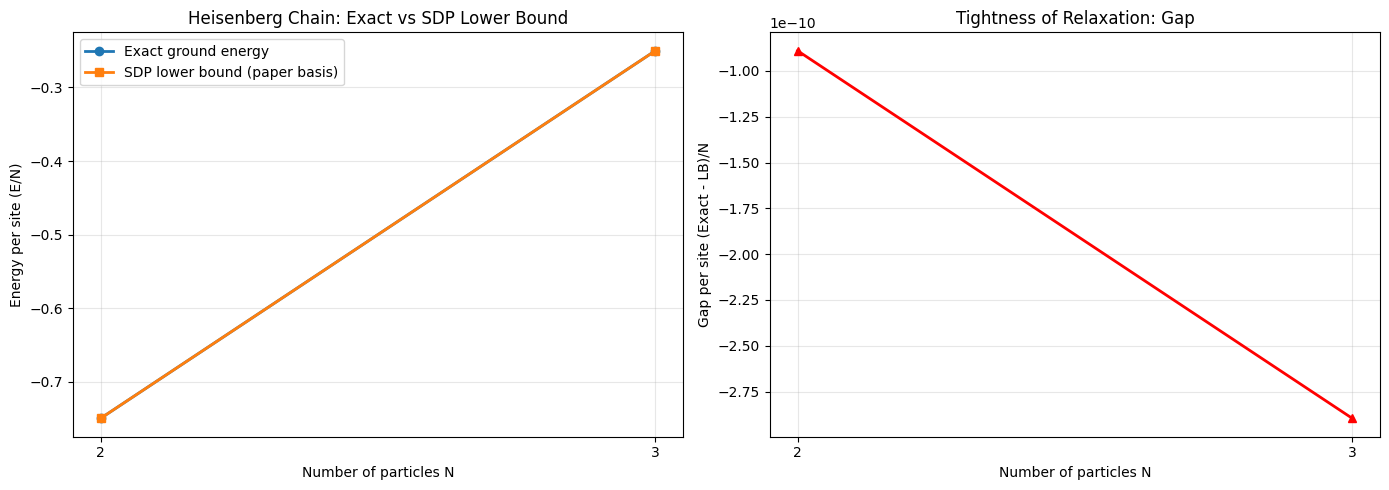

Heisenberg Chain (Paper Case B) - Exact vs SDP Comparison
N        Exact E         SDP LB          Gap             Gap/N          
--------------------------------------------------------------------------------
2        -1.50000000     -1.50000000     -1.77924564e-10 -8.89622820e-11
3        -0.75000000     -0.75000000     -8.68946359e-10 -2.89648786e-10


In [15]:
from plots import plot_paper_heisenberg_results

N_values = range(2, 4)

heisenberg_data = plot_paper_heisenberg_results(
    N_values=N_values,
    boundary="periodic",  # Paper uses periodic boundary conditions
    solver="MOSEK",
    mosek_tol=1e-9,
    per_site=True,
)

Up until $N=10$, $E_{exact}=E_{SDP}$ in the paper, so the results are consistent for low $N$. For $N=5$, this took 14mins to run. Qualitatively, we see through printing each stage that what takes the longest is by far solving the SDP.

### Heisenberg Chain with second-neighbour couplings
$$\mathcal{H} = (1/4) \sum_{i=1}^{N} \sum_{a \in \{x,y,z\}} [\sigma_i^a \sigma_{i+1}^a + J_2 \sigma_i^a \sigma_{i+2}^a]$$

### Monomials in the basis
For $J_2\leq 1$, we take
$$1, \,\, \sigma_i^a, \,\, \sigma_i^a\sigma_{i+j}^b, \,\, \sigma_i^a \sigma_{i+1}^b \sigma_{i+2}^c, \,\, \sigma_i^a \sigma_{i+1}^b \sigma_{i+2}^c \sigma_{i+3}^d, \quad i\in\{1,\cdots,N\}, \,\, j\in\{1,\cdots r\}, \,\, a,b,c,d\in\{x,y,z\}$$
For $J_2 > 1$, we take
$$1, \,\, \sigma_i^a, \,\, \sigma_i^a \sigma_{i+j}^b, \,\, \sigma_i^a \sigma_{i+2}^b \sigma_{i+4}^c, \,\, \sigma_i^a \sigma_{i+1}^b \sigma_{i+2}^c \sigma_{i+3}^d, \quad i\in\{1,\cdots,N\}, \,\, j\in\{1,\cdots r\}, \,\, a,b,c,d\in\{x,y,z\}$$

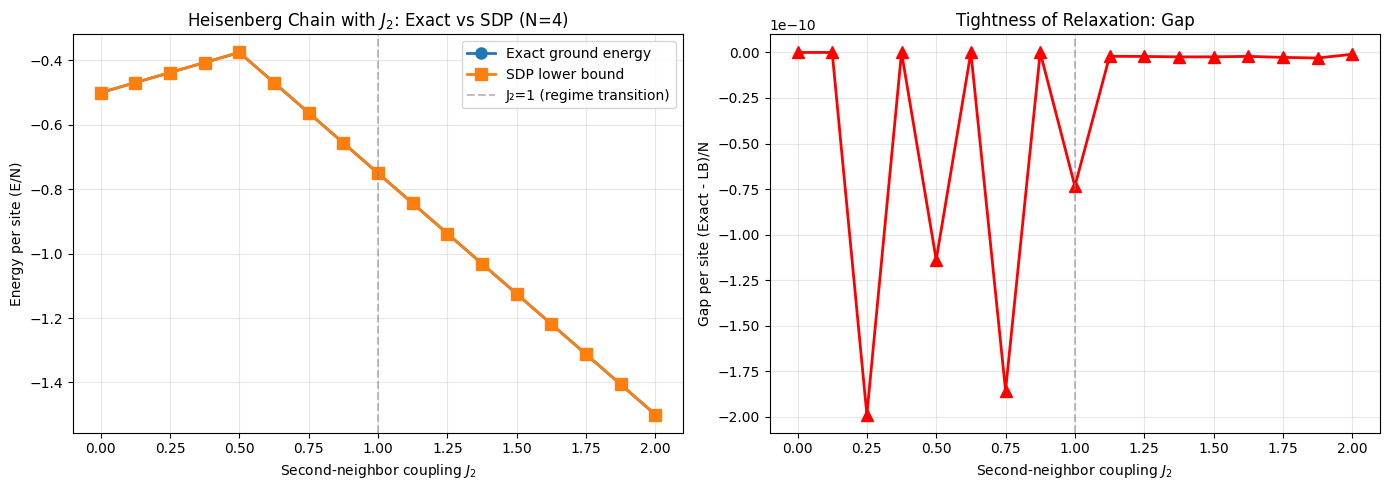

Heisenberg Chain with J2 (Paper Case C) - N=4 - Exact vs SDP Comparison
J2         Exact E         SDP LB          Gap             Gap/N           Regime         
----------------------------------------------------------------------------------------------------
0.000      -2.00000000     -2.00000000     -1.42108547e-14 -3.55271368e-15 Weak (J2<=1)   
0.125      -1.87500000     -1.87500000     -1.15463195e-14 -2.88657986e-15 Weak (J2<=1)   
0.250      -1.75000000     -1.75000000     -7.95191024e-10 -1.98797756e-10 Weak (J2<=1)   
0.375      -1.62500000     -1.62500000     -8.21565038e-15 -2.05391260e-15 Weak (J2<=1)   
0.500      -1.50000000     -1.50000000     -4.55256277e-10 -1.13814069e-10 Weak (J2<=1)   
0.625      -1.87500000     -1.87500000     -9.76996262e-15 -2.44249065e-15 Weak (J2<=1)   
0.750      -2.25000000     -2.25000000     -7.42367057e-10 -1.85591764e-10 Weak (J2<=1)   
0.875      -2.62500000     -2.62500000     -1.42108547e-14 -3.55271368e-15 Weak (J2<=1)   
1.000   

In [ ]:
from plots import plot_heisenberg_j2_vs_coupling

# Include values across weak (J2 <= 1) and strong (J2 > 1) regimes
J2_values = np.linspace(0.0, 2.0, 17) # 0, 0.125, 0.25, ..., 2.0  

heisenberg_j2_data = plot_heisenberg_j2_vs_coupling(
    N=4,
    J2_values=J2_values,
    boundary="periodic",  # Paper uses periodic boundary conditions
    solver="MOSEK",
    mosek_tol=1e-9,
    per_site=True,
)

In [ ]:
from src.optimalsdp.montecarlo import simulated_annealing, parallel_tempering
from functools import partial
import random
import time
from src.optimalsdp.bell_utils import _optimization_wrapper

import cvxpy as cp
import qutip as qt
import numpy as np
import matplotlib.pyplot as plt
import plots as plots

from spins_sdp import (
    heisenberg_hamiltonian_exact,
    ising_hamiltonian_exact,
    magnetization_qutip,
    gibbs_state_from_spectrum,
    npa_level,
    moment_matrix_dict,
    build_sdp_variables,
    dict_to_cvxpy_matrix_from_expr,
    ising_energy_expr,
    average_magnetization,
    ising_pauli_symbolic_terms,
    build_diagonality_constraints,
    build_lambda_matrix,
)

from spins_sdp.utils import *
from spins_sdp.basis_builder import *

def heisenberg_operator(N: int, boundary = "periodic") -> Operator:
    """
    Build the 1D Heisenberg Hamiltonian as a Pauli operator dictionary.
    
    H = (1/4) Σ_i Σ_a∈{x,y,z} σ_i^a σ_{i+1}^a
    
    This matches the paper's definition (case B).
    
    Args:
        N: Number of spins
        boundary: "open" or "periodic"
        
    Returns:
        Operator dictionary mapping PauliWord -> coefficient
    """
    op: Operator = {}
    
    # (1/4) sum_i sum_a σ_i^a σ_{i+1}^a
    for i in range(N):
        if i < N - 1 or boundary == "periodic":
            j = (i + 1) % N
            
            # X_i X_{i+1}
            w = PauliWord((1 << i) | (1 << j), 0)
            op[w] = op.get(w, 0.0) + 0.25
            
            # Y_i Y_{i+1}
            w = PauliWord((1 << i) | (1 << j), (1 << i) | (1 << j))
            op[w] = op.get(w, 0.0) + 0.25
            
            # Z_i Z_{i+1}
            w = PauliWord(0, (1 << i) | (1 << j))
            op[w] = op.get(w, 0.0) + 0.25
    
    return op



def logic(obj_func, L, k, seed):
    """
    YOUR SIMULATION LOGIC GOES HERE.
    
    This function takes swept parameters, fixed parameters, and a seed, 
    runs the simulation, and returns results.
    
    Args:
        parameters: Dictionary of swept parameter values, e.g. 
                   {"temperature": 300, "pressure": 1.0}
        fixed_parameters: Dictionary of fixed parameter values, e.g.
                         {"num_particles": 1000, "timestep": 0.001}
        seed: Integer seed for reproducibility
    
    Returns:
        Dictionary of results. Can contain:
        - Scalars: {"energy": 150.5, "converged": True}
        - Arrays: {"trajectory": np.array([...]), "positions": np.array([[...]])}
        - Nested dicts: {"final_state": {"positions": [...], "velocities": [...]}}
    """

    # Set seed for reproducibility
    random.seed(seed)
    np.random.seed(seed)

    #Simulated Annealing
    start = time.time()
    pt_res = parallel_tempering(obj_func=obj_func,
    N=L,
    k=k,
    num_chains= 2 , # Default: Number of CPUs
    num_epochs= 2, # How many times to swap
    steps_per_epoch= 200, # How long each CPU works before swapping
    T_min=0.01,
    T_max=2.0,
    seed=seed
    )
    end = time.time()

    result = {
        "PT_best_value": pt_res['best']['value'],
        "PT_time": end - start
        }
    
    return result



# Model parameters
N = 2
boundary = "periodic"
seed = 42


starting_set_npalevel = 1
final_set_npalevel = 2

k = 2

# create hamiltonian
H = heisenberg_hamiltonian_exact(N)
eigenvalues, eigenstates = H.eigenstates()
E0 = eigenvalues[0]
print(E0)

H_dict = heisenberg_operator(N = N, boundary = boundary)
starting_set = generate_npa_basis(N = N, k = starting_set_npalevel).words
final_set = generate_npa_basis(N = N, k = final_set_npalevel).words
adding_set = [monom for monom in final_set if monom not in starting_set]

print(len(adding_set))

relaxation = solve_pauli_relaxation(final_set, H_dict,sense = "min")
print(relaxation)


obj_func = partial(
        optimization_wrapper_spins, 
        starting_set=starting_set, 
        adding_set=adding_set, 
        hamiltonian_expression = H_dict
    )


best_values = []
for kk in range(len(adding_set)+1):
    result = logic(obj_func, len(adding_set), kk, seed)
    best_values.append(result['PT_best_value'])





-1.499999999999999
9
-1.4999999998220752
--- PT starting ---
Chains: 2
Temperatures (hot -> cold): [2.0, 0.01]


Parallel Tempering:   0%|          | 0/2 [00:00<?, ?it/s]

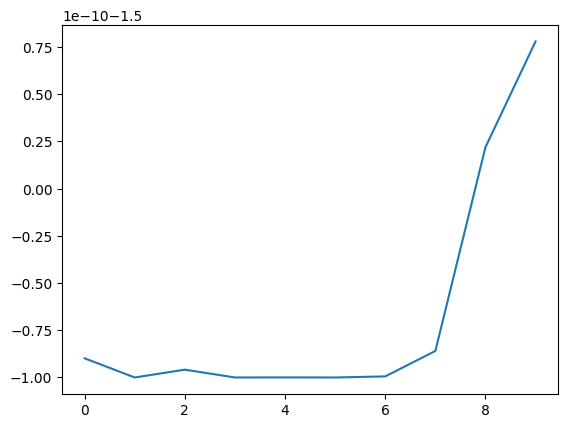

In [21]:
kk_to_plot = np.arange(len(adding_set)+1)
plt.plot(kk_to_plot,best_values)

In [17]:
print(kk_to_plot)

[0 1 2 3 4 5 6 7 8]


Seems consistent with the paper, qualitatively: A concave curve peaked at $J_2=0.5$. In the paper, they run it for $N=40$, which is just impossible here.

## SDP Solve-Time Benchmark (Quick)

This is a lightweight benchmark to see how SDP solve time scales with the **basis size**.
We sample random k-subsets of the NPA “adding set” (level `end_level` minus level `start_level`), solve the SDP, and plot timing statistics (mean ± std and min–max).

In [2]:
# Run the benchmark for multiple N values (rerun to append more datapoints)
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from spins_sdp.scripts.sdp_benchmark import compute_and_save

# Use a fresh file for by-N plots (older files may not store N per row).
out_npz = Path("spins_sdp/results/sdp_benchmark_byN.npz")

# Choose the system sizes you want to compare.
Ns_to_run = [7, 10]  # add more values if you want (e.g., 12, 15, ...)

solver = "MOSEK"
run_path = out_npz
for N_val in Ns_to_run:
    try:
        run_path = compute_and_save(
            N=int(N_val),
            model_name="heisenberg",
            model_params={},
            boundary="periodic",
            start_level=1,
            end_level=2,
            k_values=list(range(0, 17, 2)),
            num_trials=2,              # how many NEW samples to add per k, per N
            base_seed=0,
            solver=solver,
            mosek_tol=1e-9,
            solver_opts_json=None,
            out_root=Path("spins_sdp/results"),
            out_npz=out_npz,
            resume=True,
            force=False,
            append_trials=True,        # key: reruns add trials instead of doing nothing
            verbose=True,
        )
    except Exception as e:
        print(f"MOSEK failed for N={N_val} ({e}); falling back to SCS for this N.")
        run_path = compute_and_save(
            N=int(N_val),
            model_name="heisenberg",
            model_params={},
            boundary="periodic",
            start_level=1,
            end_level=2,
            k_values=list(range(0, 17, 2)),
            num_trials=2,
            base_seed=0,
            solver="SCS",
            mosek_tol=1e-9,
            solver_opts_json=None,
            out_root=Path("spins_sdp/results"),
            out_npz=out_npz,
            resume=True,
            force=False,
            append_trials=True,
            verbose=True,
        )

print("\nBenchmark output:", run_path)

Model: heisenberg, N=7, boundary=periodic
Starting set size: 22, Adding set size: 189, Final set size: 211
Total jobs: 18, Already done: 36, To compute: 18
k=  0 trial=  4 basis=  22 n=  22 m=  211 t_total=0.062s (compile 0.001, build 0.001, solve 0.060) status=optimal
k=  0 trial=  5 basis=  22 n=  22 m=  211 t_total=0.029s (compile 0.001, build 0.001, solve 0.028) status=optimal
k=  2 trial=  4 basis=  24 n=  24 m=  242 t_total=0.038s (compile 0.001, build 0.000, solve 0.036) status=optimal
k=  2 trial=  5 basis=  24 n=  24 m=  242 t_total=0.038s (compile 0.001, build 0.001, solve 0.037) status=optimal
k=  4 trial=  4 basis=  26 n=  26 m=  274 t_total=0.055s (compile 0.001, build 0.000, solve 0.053) status=optimal
k=  4 trial=  5 basis=  26 n=  26 m=  275 t_total=0.052s (compile 0.001, build 0.001, solve 0.051) status=optimal
k=  6 trial=  4 basis=  28 n=  28 m=  310 t_total=0.055s (compile 0.001, build 0.001, solve 0.053) status=optimal
k=  6 trial=  5 basis=  28 n=  28 m=  315 t_to

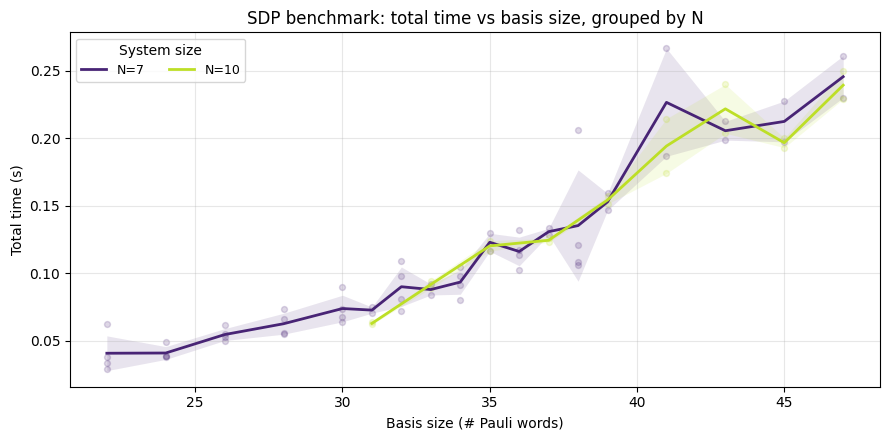

In [3]:
# Plot timing vs basis size, grouped by N
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

npz_path = Path(run_path)
if npz_path.is_dir():
    npz_path = npz_path / "data.npz"

data = dict(np.load(npz_path, allow_pickle=False))

basis_size = data["basis_size"].astype(int)
t_total = data["t_total_s"].astype(float)

Ns = data.get("N")
if Ns is None:
    raise RuntimeError(
        "This .npz does not contain per-row N. "
        "Use the new benchmark output (e.g. spins_sdp/results/sdp_benchmark_byN.npz) "
        "or rerun the benchmark after updating spins_sdp/scripts/sdp_benchmark.py."
    )
Ns = Ns.astype(int)

unique_Ns = sorted(set(Ns.tolist()))
colors = plt.cm.viridis(np.linspace(0.1, 0.9, max(1, len(unique_Ns))))

plt.figure(figsize=(9, 4.5))

for N_val, color in zip(unique_Ns, colors):
    mask = Ns == int(N_val)
    x = basis_size[mask]
    y = t_total[mask]
    if len(x) == 0:
        continue

    # Scatter all datapoints
    plt.scatter(x, y, s=18, alpha=0.18, color=color)

    # Aggregate at each basis size value for a mean±std curve.
    x_unique = np.array(sorted(set(x.tolist())), dtype=int)
    y_mean = np.array([float(np.mean(y[x == xu])) for xu in x_unique])
    y_std = np.array([float(np.std(y[x == xu])) for xu in x_unique])

    plt.plot(x_unique, y_mean, color=color, linewidth=2, label=f"N={int(N_val)}")
    if np.any(y_std > 0):
        plt.fill_between(
            x_unique,
            y_mean - y_std,
            y_mean + y_std,
            color=color,
            alpha=0.12,
            linewidth=0,
        )

plt.xlabel("Basis size (# Pauli words)")
plt.ylabel("Total time (s)")
plt.title("SDP benchmark: total time vs basis size, grouped by N")
plt.grid(True, alpha=0.3)
plt.legend(title="System size", ncols=2, fontsize=9)
plt.tight_layout()
plt.show()